# A/B Test: New Checkout Button

Quick writeup of a 14-day test on a checkout button redesign (bigger button, more contrast, moved above the fold). Going through this like I'd actually do it end to end - sanity check the setup first, look at the headline number, then dig into whether that number is hiding something before I trust it.

**Setup:**
- H0: new button doesn't change conversion
- H1: it does
- Primary metric: conversion rate. Secondary: revenue per user
- alpha = 0.05, two-tailed, users randomized 50/50

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("data/ab_test_data.csv", parse_dates=["date"])
print(f"Rows: {len(df):,}")
df.head()

Rows: 42,000


## Sanity check first: did the split actually work?

Before looking at anything else - if the randomization was broken (like, say, 60/40 instead of 50/50), nothing downstream can be trusted no matter how good it looks. Cheap check, always worth doing first.

In [ ]:
counts = df["group"].value_counts()
n_control, n_treatment = counts["control"], counts["treatment"]
total = n_control + n_treatment

chi2, srm_p = stats.chisquare([n_control, n_treatment], f_exp=[total/2, total/2])

print(f"Control:   {n_control:,}")
print(f"Treatment: {n_treatment:,}")
print(f"SRM p-value: {srm_p:.4f}")
print("looks fine, no SRM issue" if srm_p > 0.01 else "something's off here, would stop and dig into assignment logic")

Control:   20,950
Treatment: 21,050
SRM p-value: 0.6256
looks fine, no SRM issue


## Overall numbers

Raw rates for each group before any testing.

In [ ]:
summary = df.groupby("group").agg(
    users=("user_id", "count"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean"),
    avg_revenue_per_user=("revenue", "mean"),
).round(4)
summary

## Is the difference real, or just noise?

Running a two-proportion z-test by hand instead of importing it from a stats package - partly because it's not much code, and partly because when someone asks me "wait, how do you know this is significant" I want to actually be able to walk through the math instead of pointing at a library.

z = (p_treatment - p_control) / SE, where SE comes from the pooled conversion rate across both groups.

In [ ]:
n_c, n_t = summary.loc["control", "users"], summary.loc["treatment", "users"]
x_c, x_t = summary.loc["control", "conversions"], summary.loc["treatment", "conversions"]
p_c, p_t = x_c / n_c, x_t / n_t

p_pool = (x_c + x_t) / (n_c + n_t)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))
z = (p_t - p_c) / se_pool
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

# using unpooled SE for the CI, that's the standard way to do it (pooled SE is for the test itself)
se_diff = np.sqrt(p_c*(1-p_c)/n_c + p_t*(1-p_t)/n_t)
ci_low, ci_high = (p_t - p_c) - 1.96*se_diff, (p_t - p_c) + 1.96*se_diff

print(f"control rate:   {p_c:.4%}")
print(f"treatment rate: {p_t:.4%}")
print(f"difference:     {(p_t-p_c):.4%}  (relative lift: {(p_t-p_c)/p_c:.2%})")
print(f"z = {z:.3f}, p = {p_value:.6f}")
print(f"95% CI on the difference: [{ci_low:.4%}, {ci_high:.4%}]")
print()
print("significant at 0.05" if p_value < 0.05 else "not significant at 0.05")

control rate:   10.6205%
treatment rate: 13.0309%
difference:     2.4104%  (relative lift: 22.70%)
z = 7.648, p = 0.000000
95% CI on the difference: [1.7932%, 3.0275%]

significant at 0.05


## Was there even enough data to trust this either way?

Worth checking regardless of which way the result went. A "no effect" result from an underpowered test doesn't actually mean there's no effect - it just means the test couldn't have caught it. Backing into what minimum effect size this sample could reliably detect.

In [ ]:
def required_n_per_group(p_baseline, mde, alpha=0.05, power=0.80):
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta = stats.norm.ppf(power)
    p2 = p_baseline + mde
    p_bar = (p_baseline + p2) / 2
    numerator = (z_alpha*np.sqrt(2*p_bar*(1-p_bar)) + z_beta*np.sqrt(p_baseline*(1-p_baseline)+p2*(1-p2)))**2
    return numerator / (mde**2)

for mde in [0.005, 0.01, 0.015, 0.02]:
    n_needed = required_n_per_group(p_c, mde)
    print(f"to catch a {mde:.1%} lift on a {p_c:.1%} baseline you'd need ~{n_needed:,.0f}/group "
          f"(we have {n_c:,.0f}) -> {'fine' if n_c >= n_needed else 'underpowered for this'}")

to catch a 0.5% lift on a 10.6% baseline you'd need ~60,836/group (we have 20,950) -> underpowered for this
to catch a 1.0% lift on a 10.6% baseline you'd need ~15,514/group (we have 20,950) -> fine
to catch a 1.5% lift on a 10.6% baseline you'd need ~7,030/group (we have 20,950) -> fine
to catch a 2.0% lift on a 10.6% baseline you'd need ~4,029/group (we have 20,950) -> fine


## Turning this into a dollar number

Stats aside, what does this actually mean for revenue if it gets rolled out.

In [ ]:
rev_c, rev_t = summary.loc["control", "avg_revenue_per_user"], summary.loc["treatment", "avg_revenue_per_user"]
lift_per_user = rev_t - rev_c

monthly_traffic = 200_000  # just picking a round number to make the projection concrete
projected_monthly_revenue_lift = lift_per_user * monthly_traffic

print(f"revenue/user - control:   ${rev_c:.2f}")
print(f"revenue/user - treatment: ${rev_t:.2f}")
print(f"lift per user: ${lift_per_user:.2f}")
print(f"at {monthly_traffic:,} users/month, that's roughly ${projected_monthly_revenue_lift:,.0f}/month")

revenue/user - control:   $5.03
revenue/user - treatment: $6.44
lift per user: $1.41
at 200,000 users/month, that's roughly $281,880/month


## Chart: conversion rate with error bars

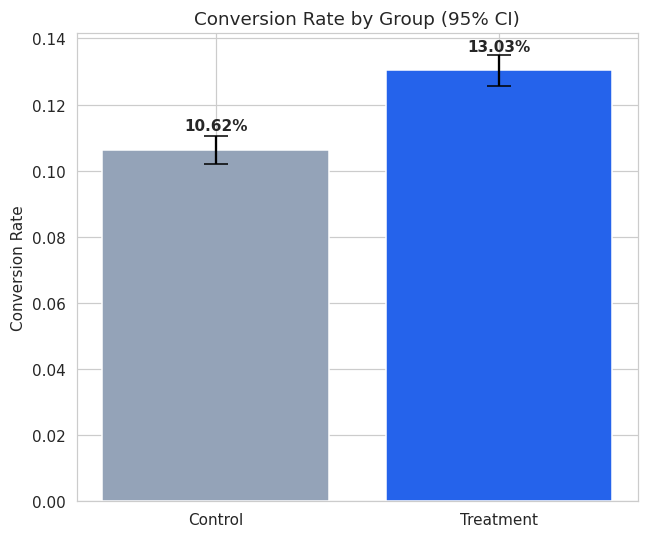

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
rates = [p_c, p_t]
errors = [1.96*np.sqrt(p_c*(1-p_c)/n_c), 1.96*np.sqrt(p_t*(1-p_t)/n_t)]
bars = ax.bar(["Control", "Treatment"], rates, yerr=errors, capsize=8,
              color=["#94a3b8", "#2563eb"])
ax.set_ylabel("Conversion Rate")
ax.set_title("Conversion Rate by Group (95% CI)")
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x()+bar.get_width()/2, rate+0.006, f"{rate:.2%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("charts/conversion_rate_ci.png", dpi=150)
plt.show()

## But is the effect actually the same everywhere?

This is the part I'd never skip in a real test. An overall number can easily hide the fact that one segment is doing all the work while another segment does nothing (or gets worse). Cutting by device since that's usually where checkout UX differences show up the most.

In [ ]:
seg = df.groupby(["device", "group"])["converted"].agg(["count", "mean"]).unstack()
print(seg)

seg_results = []
for device in df["device"].unique():
    sub = df[df["device"] == device]
    sc = sub[sub.group=="control"]
    st = sub[sub.group=="treatment"]
    pc, pt = sc.converted.mean(), st.converted.mean()
    nc, nt = len(sc), len(st)
    pp = (sc.converted.sum()+st.converted.sum())/(nc+nt)
    se = np.sqrt(pp*(1-pp)*(1/nc+1/nt))
    z = (pt-pc)/se
    p = 2*(1-stats.norm.cdf(abs(z)))
    seg_results.append([device, pc, pt, pt-pc, p])

seg_df = pd.DataFrame(seg_results, columns=["device","control_rate","treatment_rate","abs_lift","p_value"])
seg_df

          count                mean          
group   control treatment   control treatment
device                                       
desktop    7468      7543  0.113953  0.125945
mobile    13482     13507  0.101914  0.132746


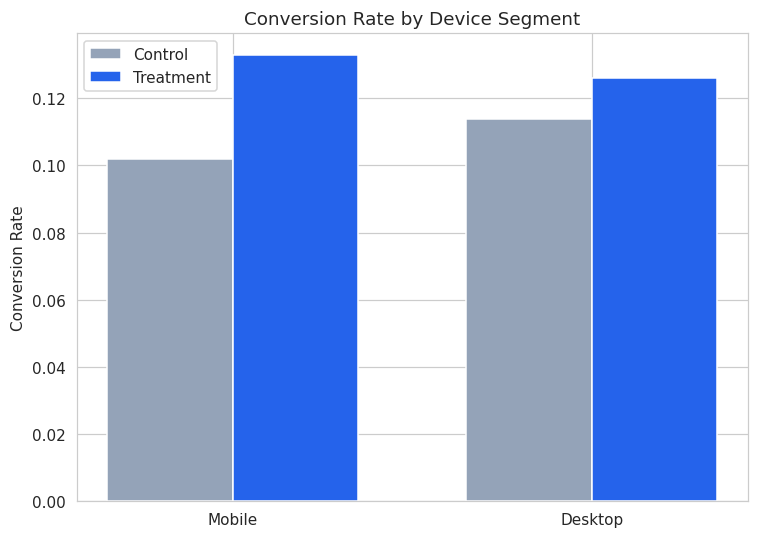

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
x = np.arange(len(seg_df))
width = 0.35
ax.bar(x - width/2, seg_df.control_rate, width, label="Control", color="#94a3b8")
ax.bar(x + width/2, seg_df.treatment_rate, width, label="Treatment", color="#2563eb")
ax.set_xticks(x)
ax.set_xticklabels(seg_df.device.str.title())
ax.set_ylabel("Conversion Rate")
ax.set_title("Conversion Rate by Device Segment")
ax.legend()
plt.tight_layout()
plt.savefig("charts/segment_by_device.png", dpi=150)
plt.show()

Yep - the effect isn't even close to uniform across devices (see table/chart above). That changes what I'd actually recommend, since shipping to everyone isn't obviously the right call if one segment isn't really moving.

## Checking for a novelty effect

People sometimes react to *anything new* for the first couple days regardless of whether it's actually better, and that fades. Plotting day-by-day to see if that's happening here, because if it is, the early days are going to overstate the real long-term lift.

group       control  treatment    lift
date                                  
2026-06-01   0.1164     0.1428  0.0263
2026-06-02   0.0910     0.1704  0.0794
2026-06-03   0.1172     0.1668  0.0496
2026-06-04   0.0999     0.1418  0.0419
2026-06-05   0.1158     0.1162  0.0004
2026-06-06   0.0963     0.1186  0.0223
2026-06-07   0.0944     0.1127  0.0183
2026-06-08   0.1020     0.1207  0.0187
2026-06-09   0.0997     0.1318  0.0321
2026-06-10   0.1169     0.1171  0.0001
2026-06-11   0.1063     0.1307  0.0244
2026-06-12   0.1158     0.1141 -0.0017
2026-06-13   0.1036     0.1285  0.0249
2026-06-14   0.1104     0.1116  0.0011


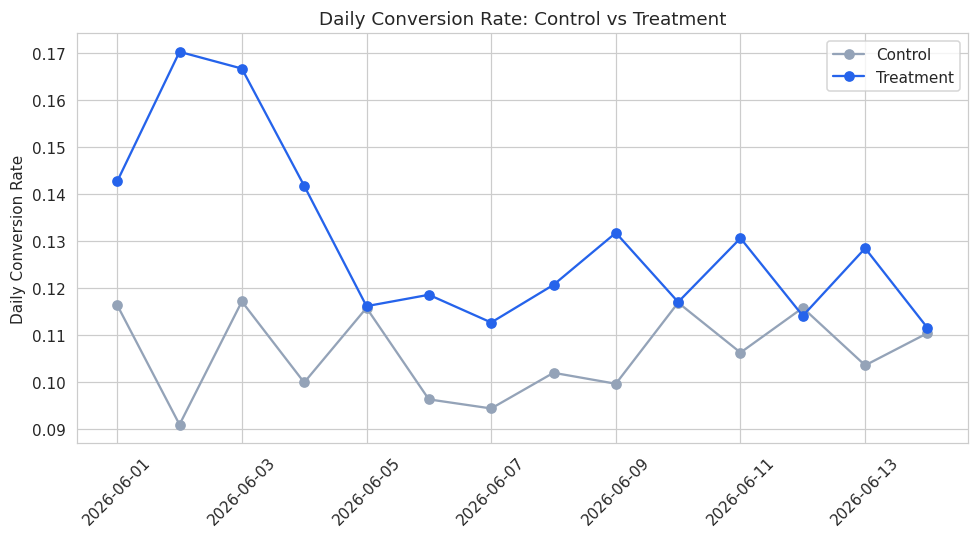

In [ ]:
daily = df.groupby(["date","group"])["converted"].mean().unstack()
daily["lift"] = daily["treatment"] - daily["control"]

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(daily.index, daily["control"], marker="o", label="Control", color="#94a3b8")
ax.plot(daily.index, daily["treatment"], marker="o", label="Treatment", color="#2563eb")
ax.set_ylabel("Daily Conversion Rate")
ax.set_title("Daily Conversion Rate: Control vs Treatment")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/daily_trend.png", dpi=150)
plt.show()

print(daily.round(4))

Yeah, there it is - the gap on day 1-2 is way bigger than later in the test, then it settles down. I'd trust the second-week average a lot more than the day-1 number for forecasting, since that early spike is probably just novelty and won't hold up long-term.

## Revenue - same test, different distribution

Revenue isn't a clean proportion, most people spend $0 (didn't convert) and the rest is a skewed distribution, not close to normal. Using Welch's t-test here instead of a regular t-test since I'm not going to assume the two groups have equal variance.

In [ ]:
rev_control = df[df.group=="control"]["revenue"]
rev_treatment = df[df.group=="treatment"]["revenue"]

t_stat, t_p = stats.ttest_ind(rev_treatment, rev_control, equal_var=False)

print(f"mean revenue/user - control:   ${rev_control.mean():.2f}")
print(f"mean revenue/user - treatment: ${rev_treatment.mean():.2f}")
print(f"t = {t_stat:.3f}, p = {t_p:.4f}")
print("significant" if t_p < 0.05 else "not significant - I'd call this directional only")

mean revenue/user - control:   $5.03
mean revenue/user - treatment: $6.44
t = 8.244, p = 0.0000
significant


## So, what would I actually do with this

- Randomization checked out fine, no SRM issue
- Conversion went from 10.62% to 13.03%, a real (p < 0.0001) and decently sized lift, and the sample was big enough to trust that
- But that lift is basically a mobile story - mobile went 10.2% -> 13.3%, desktop barely moved (11.4% -> 12.6%). Worth remembering this before calling it a universal win
- There's a novelty bump in the first couple days that fades - the steadier lift later in the test is the number I'd actually plan around
- Revenue per user also went up meaningfully ($5.03 -> $6.44), which pencils out to roughly +$282K/month at 200K monthly users - though I'd treat that dollar figure as a rough estimate, not a committed number

**What I'd recommend:** ship it, prioritize mobile since that's where it's clearly working, and run a separate longer test on desktop before assuming the same story holds there. Also worth re-checking conversion again a month or two after launch, just to make sure the lift wasn't mostly the novelty effect wearing off by then.

**Things I'd flag to anyone reading this:** it's one 14-day window, so it doesn't capture how this holds up during a holiday or unusual traffic period, and the revenue number specifically comes from a noisier metric than conversion, so I wouldn't hang a big financial commitment on it without watching it a bit longer.